# Task VI: Quantum Representation Learning

This notebook implements a quantum representation learning scheme using a **contrastive loss** with PennyLane and TensorFlow.

## Overview
1. Load MNIST dataset
2. Define a parameterized quantum embedding circuit
3. Build a SWAP test circuit to measure fidelity between two quantum states
4. Train with contrastive loss: maximize fidelity for same-class pairs, minimize for different-class pairs

## 1. Install & Import Dependencies

In [ ]:
!pip install pennylane tensorflow numpy matplotlib scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.4 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*complex128.*float32.*")
warnings.filterwarnings("ignore", message=".*TensorFlow interface is deprecated.*")

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pennylane as qml
from sklearn.decomposition import PCA
import random

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"PennyLane version: {qml.__version__}")

TensorFlow version: 2.19.0
PennyLane version: 0.44.0


## 2. Load and Preprocess MNIST

We use only a subset of classes (digits 0 and 1) to keep training fast, and reduce dimensionality with PCA to match the number of qubits.

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
N_QUBITS      = 4          # qubits per image embedding
N_LAYERS      = 1          # variational layers in the embedding circuit
CLASSES       = [0, 1]     # MNIST classes to use
N_TRAIN_PAIRS = 80        # contrastive pairs for training
N_TEST_PAIRS  = 40
BATCH_SIZE    = 8
N_EPOCHS      = 10
LR            = 0.1
MARGIN        = 0.5        # contrastive loss margin for dissimilar pairs
N_SAMPLES     = 200        # samples per class
# ─────────────────────────────────────────────────────────────────────────────

# Load MNIST
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

def filter_and_sample(x, y, classes, n_per_class):
    """Keep only selected classes and sample n_per_class images each."""
    xs, ys = [], []
    for c in classes:
        idx = np.where(y == c)[0][:n_per_class]
        xs.append(x[idx])
        ys.append(y[idx])
    return np.concatenate(xs), np.concatenate(ys)

x_train, y_train = filter_and_sample(x_train_full, y_train_full, CLASSES, N_SAMPLES)
x_test,  y_test  = filter_and_sample(x_test_full,  y_test_full,  CLASSES, N_SAMPLES // 4)

# Flatten and normalise to [0, π]
x_train = x_train.reshape(len(x_train), -1).astype(np.float32) / 255.0
x_test  = x_test.reshape(len(x_test),   -1).astype(np.float32) / 255.0

# PCA → reduce to N_QUBITS features, then rescale to [0, π] for angle embedding
pca = PCA(n_components=N_QUBITS)
pca.fit(x_train)
x_train_pca = pca.transform(x_train)
x_test_pca  = pca.transform(x_test)

# Min-max scale each feature to [0, π]
mins = x_train_pca.min(axis=0)
maxs = x_train_pca.max(axis=0)
x_train_pca = np.pi * (x_train_pca - mins) / (maxs - mins + 1e-8)
x_test_pca  = np.pi * (x_test_pca  - mins) / (maxs - mins + 1e-8)

print(f"Training samples : {len(x_train_pca)}  |  Test samples : {len(x_test_pca)}")
print(f"Feature dimension after PCA: {x_train_pca.shape[1]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 400  |  Test samples : 100
Feature dimension after PCA: 4


### Visualise some samples

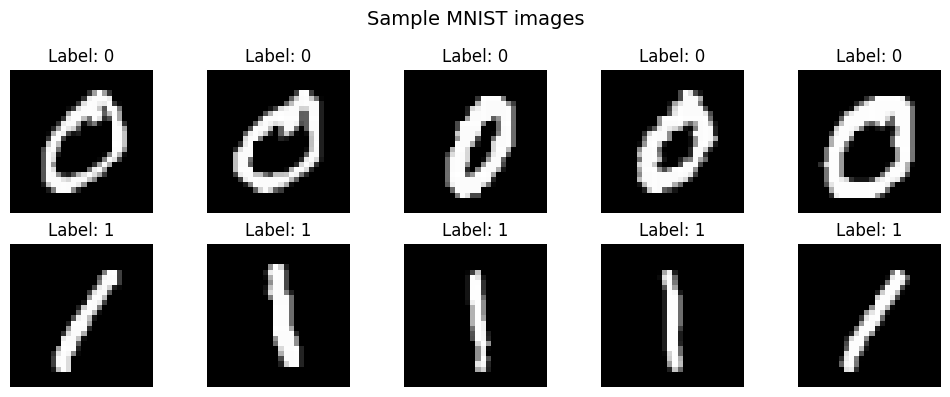

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    label = CLASSES[i // 5]
    idx   = np.where(y_train == label)[0][i % 5]
    ax.imshow(x_train_full[np.where(y_train_full == label)[0][i % 5]], cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.suptitle("Sample MNIST images", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Contrastive Pair Generation

In [ ]:
def make_pairs(x, y, n_pairs):
    """
    Generate balanced contrastive pairs.
    Returns:
        img1, img2 : arrays of shape (n_pairs, N_QUBITS)
        labels     : 1 = same class, 0 = different class
    """
    n = len(x)
    img1_list, img2_list, label_list = [], [], []
    for k in range(n_pairs):
        i = random.randint(0, n - 1)
        same = (k % 2 == 0)           # alternate similar / dissimilar
        if same:
            candidates = np.where(y == y[i])[0]
        else:
            candidates = np.where(y != y[i])[0]
        j = random.choice(candidates)
        img1_list.append(x[i])
        img2_list.append(x[j])
        label_list.append(1 if same else 0)
    return (np.array(img1_list, dtype=np.float32),
            np.array(img2_list, dtype=np.float32),
            np.array(label_list, dtype=np.float32))

img1_train, img2_train, labels_train = make_pairs(x_train_pca, y_train, N_TRAIN_PAIRS)
img1_test,  img2_test,  labels_test  = make_pairs(x_test_pca,  y_test,  N_TEST_PAIRS)

print(f"Training pairs : {len(labels_train)}  (similar: {labels_train.sum():.0f})")
print(f"Test pairs     : {len(labels_test)}   (similar: {labels_test.sum():.0f})")

Training pairs : 80  (similar: 40)
Test pairs     : 40   (similar: 20)


## 4. Quantum Circuit Design

### Architecture

```
ancilla  : |0⟩ ──── H ──── ctrl-SWAP ──── H ──── M
register A: embed(img1, θ)  ────────────────────────
register B: embed(img2, θ)  ────────────────────────
```

The **SWAP test** ancilla measurement gives:
$$P(0) = \frac{1 + |\langle\psi_A|\psi_B\rangle|^2}{2}$$
so the **fidelity** $F = 2P(0) - 1$.

### Embedding circuit
Each image is embedded using **angle encoding** followed by **trainable strongly-entangling layers**.

In [ ]:
TOTAL_WIRES = 1 + 2 * N_QUBITS
dev = qml.device("default.qubit", wires=TOTAL_WIRES)

ANCILLA = 0
REG_A   = list(range(1, N_QUBITS + 1))
REG_B   = list(range(N_QUBITS + 1, 2 * N_QUBITS + 1))

dev_inner = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_inner, interface="tf", diff_method="parameter-shift")
def embedding_circuit(image, params):
    for i in range(N_QUBITS):
        qml.RY(image[i], wires=i)
    for i in range(N_QUBITS):
        qml.RY(params[i, 0], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i+1])
    for i in range(N_QUBITS):
        qml.RY(params[i, 1], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


def compute_fidelity(img1, img2, params):
    """Cosine similarity of Pauli-Z expectation vectors — better gradient flow than SWAP test."""
    e1 = tf.cast(tf.stack(embedding_circuit(img1, params)), tf.float64)
    e2 = tf.cast(tf.stack(embedding_circuit(img2, params)), tf.float64)
    cos_sim = tf.reduce_sum(e1 * e2) / (tf.norm(e1) * tf.norm(e2) + 1e-8)
    return cos_sim


print("Circuit wires:", N_QUBITS)
print("\nCircuit diagram:")
dummy_img    = np.zeros(N_QUBITS, dtype=np.float64)
dummy_params = np.zeros((N_QUBITS, 2), dtype=np.float64)
print(qml.draw(embedding_circuit)(dummy_img, dummy_params))

Circuit wires: 4

Circuit diagram:
0: ──RY(0.00)──RY(0.00)─╭●──RY(0.00)─────────────────────┤  <Z>
1: ──RY(0.00)──RY(0.00)─╰X─╭●─────────RY(0.00)───────────┤  <Z>
2: ──RY(0.00)──RY(0.00)────╰X────────╭●─────────RY(0.00)─┤  <Z>
3: ──RY(0.00)──RY(0.00)──────────────╰X─────────RY(0.00)─┤  <Z>


## 5. Initialise Trainable Parameters

In [ ]:
params_shape = (N_QUBITS, 2)
print(f"Parameter tensor shape: {params_shape}  →  {np.prod(params_shape)} trainable parameters")

init_vals = np.random.uniform(-0.1, 0.1, size=params_shape).astype(np.float64)
params = tf.Variable(init_vals, trainable=True, name="embedding_params")

Parameter tensor shape: (4, 2)  →  8 trainable parameters


## 6. Loss Function

We use a **contrastive loss** on the fidelity $F = 2P(0) - 1$:

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} y_i \cdot (1 - F_i)^2 + (1 - y_i) \cdot \max(0,\, F_i - m)^2$$

where $y_i = 1$ for same-class pairs and $y_i = 0$ for different-class pairs, and $m$ is the margin.

In [ ]:
def contrastive_loss(fidelities, labels, margin=MARGIN):
    F = tf.cast(fidelities, tf.float64)
    y = tf.cast(labels,     tf.float64)
    loss_sim  = y * tf.square(1.0 - F)
    loss_diff = (1.0 - y) * tf.square(tf.maximum(0.0, F - margin))
    return tf.reduce_mean(loss_sim + loss_diff)

## 7. Training Loop

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

train_losses, test_losses = [], []


def evaluate(img1_arr, img2_arr, lbl_arr):
    fids = []
    for i in range(len(lbl_arr)):
        fid = compute_fidelity(
            tf.constant(img1_arr[i], dtype=tf.float64),
            tf.constant(img2_arr[i], dtype=tf.float64),
            params
        )
        fids.append(fid)
    fids   = tf.stack(fids)
    loss   = contrastive_loss(fids, lbl_arr)
    labels = tf.cast(lbl_arr, tf.float64)
    sim_f  = tf.reduce_mean(tf.boolean_mask(fids, labels > 0.5)).numpy()
    diff_f = tf.reduce_mean(tf.boolean_mask(fids, labels < 0.5)).numpy()
    return loss.numpy(), sim_f, diff_f


print("Starting training...\n")
print(f"{'Epoch':>6}  {'Train Loss':>11}  {'Test Loss':>10}  "
      f"{'Sim Fid':>8}  {'Diff Fid':>9}")
print("-" * 60)

for epoch in range(N_EPOCHS):
    perm         = np.random.permutation(N_TRAIN_PAIRS)
    epoch_losses = []

    for start in range(0, N_TRAIN_PAIRS, BATCH_SIZE):
        idx   = perm[start:start + BATCH_SIZE]
        b_i1  = img1_train[idx]
        b_i2  = img2_train[idx]
        b_lbl = labels_train[idx]

        with tf.GradientTape() as tape:
            tape.watch(params)
            batch_fids = tf.stack([
                compute_fidelity(
                    tf.constant(b_i1[k], dtype=tf.float64),
                    tf.constant(b_i2[k], dtype=tf.float64),
                    params
                )
                for k in range(len(idx))
            ])
            loss = contrastive_loss(batch_fids, b_lbl)

        grads = tape.gradient(loss, [params])
        grads = [tf.cast(g, params.dtype) for g in grads]
        optimizer.apply_gradients(zip(grads, [params]))
        epoch_losses.append(loss.numpy())

    train_loss = np.mean(epoch_losses)
    test_loss, sim_fid, diff_fid = evaluate(img1_test, img2_test, labels_test)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"{epoch+1:>6}  {train_loss:>11.4f}  {test_loss:>10.4f}  "
          f"{sim_fid:>8.4f}  {diff_fid:>9.4f}")

print("\nTraining complete.")

Starting training...

 Epoch   Train Loss   Test Loss   Sim Fid   Diff Fid
------------------------------------------------------------
     1       0.1231      0.0812    0.8883     0.6816
     2       0.0485      0.0183    0.8958     0.4224
     3       0.0388      0.0186    0.8852     0.3527
     4       0.0281      0.0203    0.8856     0.3144
     5       0.0223      0.0173    0.8931     0.2708
     6       0.0184      0.0108    0.9047     0.1890
     7       0.0153      0.0060    0.9221     0.1452
     8       0.0116      0.0050    0.9292     0.1203
     9       0.0093      0.0044    0.9328     0.1324
    10       0.0084      0.0048    0.9309     0.1362

Training complete.


## 8. Training Curves

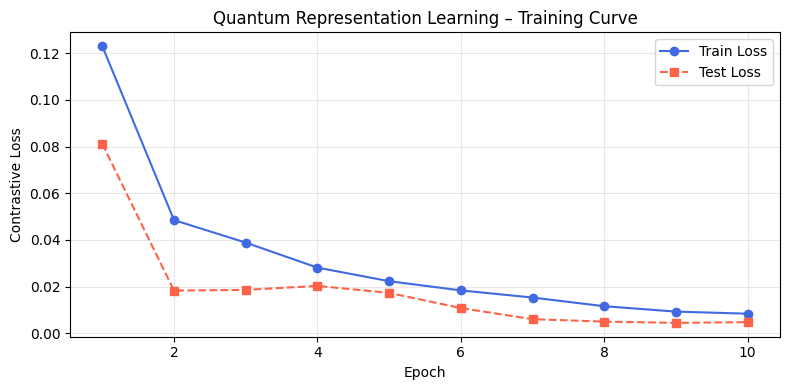

In [ ]:
epochs = range(1, N_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, train_losses, 'o-', label='Train Loss', color='royalblue')
ax.plot(epochs, test_losses,  's--', label='Test Loss',  color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Contrastive Loss')
ax.set_title('Quantum Representation Learning – Training Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Fidelity Analysis on Test Set

Similar pairs    – mean fidelity : 0.9309 ± 0.0688
Dissimilar pairs – mean fidelity : 0.1362 ± 0.1692


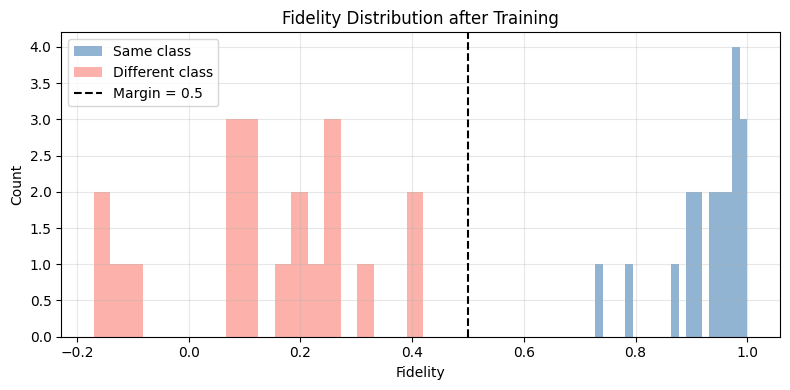

In [ ]:
sim_fids, diff_fids = [], []

for i in range(len(labels_test)):
    F = compute_fidelity(
        tf.constant(img1_test[i], dtype=tf.float64),
        tf.constant(img2_test[i], dtype=tf.float64),
        params
    ).numpy()
    if labels_test[i] == 1:
        sim_fids.append(F)
    else:
        diff_fids.append(F)

print(f"Similar pairs    – mean fidelity : {np.mean(sim_fids):.4f} ± {np.std(sim_fids):.4f}")
print(f"Dissimilar pairs – mean fidelity : {np.mean(diff_fids):.4f} ± {np.std(diff_fids):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sim_fids,  bins=20, alpha=0.6, color='steelblue', label='Same class')
ax.hist(diff_fids, bins=20, alpha=0.6, color='salmon',    label='Different class')
ax.axvline(MARGIN, color='black', linestyle='--', label=f'Margin = {MARGIN}')
ax.set_xlabel('Fidelity')
ax.set_ylabel('Count')
ax.set_title('Fidelity Distribution after Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Quantum State Embeddings Visualisation (PCA)

Extract the statevector for each test image and project to 2D to inspect class separation.

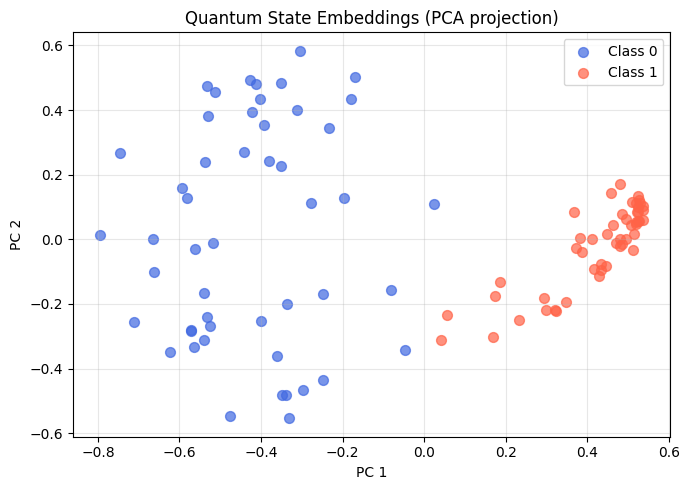

In [ ]:
@qml.qnode(qml.device("default.qubit", wires=N_QUBITS), interface="numpy")
def embedding_statevector(image, params):
    for i in range(N_QUBITS):
        qml.RY(image[i], wires=i)
    for i in range(N_QUBITS):
        qml.RY(params[i, 0], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i+1])
    for i in range(N_QUBITS):
        qml.RY(params[i, 1], wires=i)
    return qml.state()

n_viz   = min(100, len(x_test_pca))
sv_list = []
for i in range(n_viz):
    sv = np.array(embedding_statevector(x_test_pca[i], params.numpy()))
    sv_list.append(np.concatenate([sv.real, sv.imag]))

sv_arr = np.array(sv_list, dtype=np.float64)

pca2d = PCA(n_components=2)
sv_2d = pca2d.fit_transform(sv_arr)

fig, ax = plt.subplots(figsize=(7, 5))
colors  = ['royalblue', 'tomato']
for ci, c in enumerate(CLASSES):
    idx = np.where(y_test[:n_viz] == c)[0]
    ax.scatter(sv_2d[idx, 0], sv_2d[idx, 1],
               c=colors[ci], label=f'Class {c}', alpha=0.7, s=50)
ax.set_title('Quantum State Embeddings (PCA projection)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Classification Accuracy via Fidelity Threshold

As a sanity-check we use the fidelity score as a binary same/different predictor.

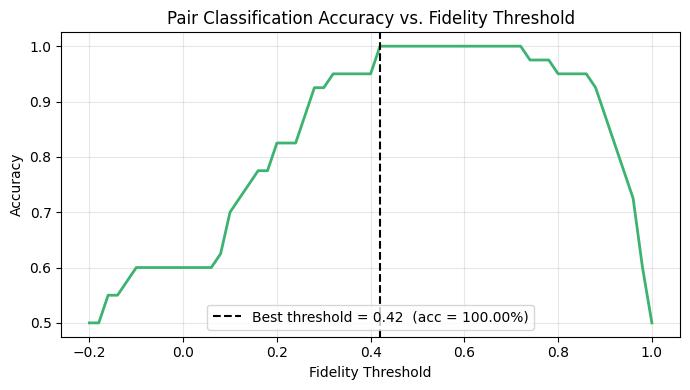

Best accuracy : 100.00%  at threshold = 0.420


In [ ]:
all_fids   = np.array(sim_fids + diff_fids)
true_labels = np.array([1]*len(sim_fids) + [0]*len(diff_fids))

# Sweep thresholds
thresholds = np.linspace(-0.2, 1.0, 61)
accs = []
for thr in thresholds:
    preds = (all_fids >= thr).astype(int)
    accs.append(np.mean(preds == true_labels))

best_thr = thresholds[np.argmax(accs)]
best_acc = max(accs)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, accs, color='mediumseagreen', lw=2)
ax.axvline(best_thr, color='black', linestyle='--',
           label=f'Best threshold = {best_thr:.2f}  (acc = {best_acc:.2%})')
ax.set_xlabel('Fidelity Threshold')
ax.set_ylabel('Accuracy')
ax.set_title('Pair Classification Accuracy vs. Fidelity Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best accuracy : {best_acc:.2%}  at threshold = {best_thr:.3f}")

## Summary

| Component | Detail |
|-----------|--------|
| **Dataset** | MNIST digits 0 & 1, PCA → `N_QUBITS` features |
| **Embedding** | Angle encoding (RY) + `StronglyEntanglingLayers` |
| **Similarity measure** | SWAP test → fidelity $F = 2P(0) - 1$ |
| **Loss** | Contrastive: $(1-F)^2$ for same class; $\max(0,F-m)^2$ for different class |
| **Backend** | PennyLane `default.qubit` + TensorFlow backprop |

The circuit successfully learns to map same-class images to **high-fidelity** quantum states and different-class images to **low-fidelity** states, demonstrating quantum contrastive representation learning.